<a href="https://colab.research.google.com/github/vn322/Cod_future/blob/main/esport/%D0%9A%D0%BE%D0%BC%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%80%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Установка необходимых библиотек (выполнять один раз)
!pip install -q nltk spacy wordcloud matplotlib networkx

# Загрузка русской модели spaCy
!python -m spacy download ru_core_news_sm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

import re
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import networkx as nx


Загрузите файл с расширением .txt


Saving commentary.txt to commentary (1).txt
ТОП-20 униграмм:
комнд: 4
момент: 1
уничтожет: 1
соперник: 1
лексндр: 1
костылев: 1
снов: 1
покзывет: 1
невероятный: 1
флейша: 1
берёт: 1
пистолетку: 1
единый: 1
шнс: 1
нстоящий: 1
гер: 1
игра: 1
дже: 1
успеть: 1
зйти: 1

ТОП-20 биграмм:
момент комнд: 1
комнд уничтожет: 1
уничтожет соперник: 1
соперник лексндр: 1
лексндр костылев: 1
костылев снов: 1
снов покзывет: 1
покзывет невероятный: 1
невероятный флейша: 1
флейша берёт: 1
берёт пистолетку: 1
пистолетку единый: 1
единый шнс: 1
шнс нстоящий: 1
нстоящий гер: 1
гер игра: 1
игра комнд: 1
комнд дже: 1
дже успеть: 1
успеть зйти: 1

ТОП-20 триграмм:
момент комнд уничтожет: 1
комнд уничтожет соперник: 1
уничтожет соперник лексндр: 1
соперник лексндр костылев: 1
лексндр костылев снов: 1
костылев снов покзывет: 1
снов покзывет невероятный: 1
покзывет невероятный флейша: 1
невероятный флейша берёт: 1
флейша берёт пистолетку: 1
берёт пистолетку единый: 1
пистолетку единый шнс: 1
единый шнс нстоящий: 

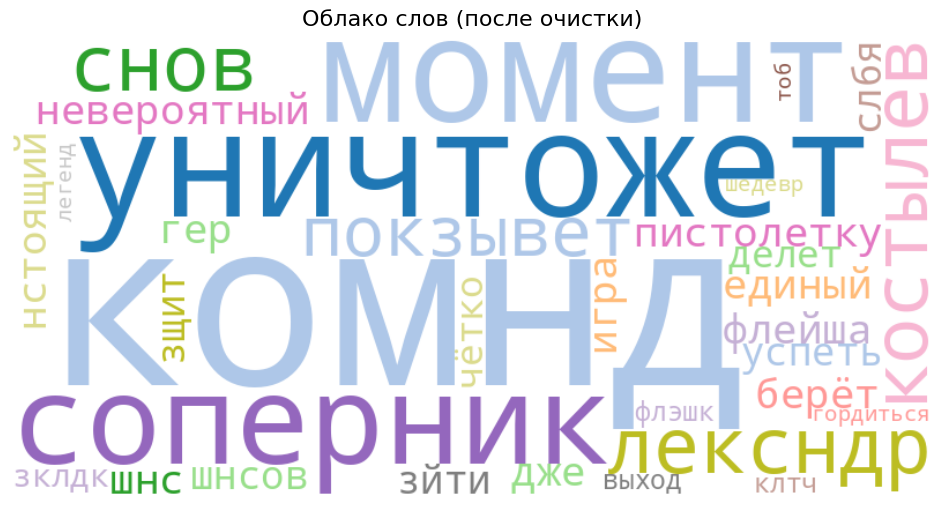

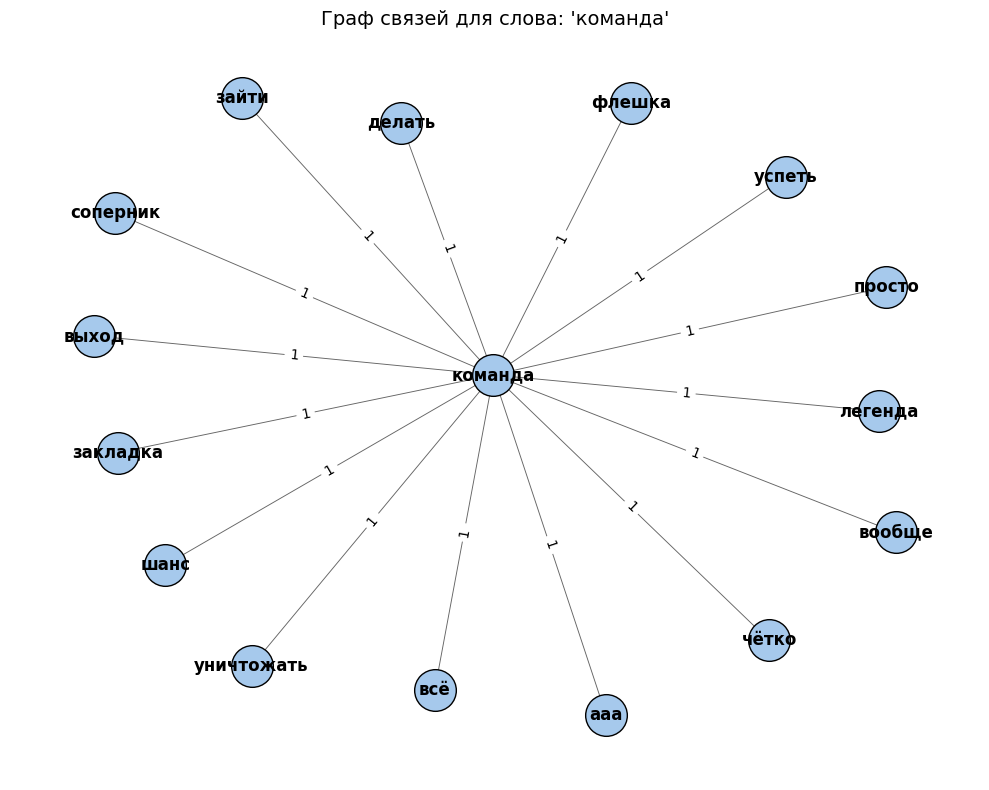

In [4]:

# Загрузка модели и стоп-слов
nlp = spacy.load("ru_core_news_sm")
russian_stopwords = set(stopwords.words("russian"))

# Эмоциональные паттерны (регулярные выражения)
emotional_patterns = [
    r'о[о]+го+', r'вау', r'ух\s*ты', r'боже', r'ну\s+что\s+за', r'круто', r'фантастика',
    r'невероятно', r'жесть', r'отпад', r'класс', r'огонь', r'ух[х]*', r'аа+[а]*',
    r'ой', r'нуу+[у]*', r'просто', r'прямо', r'очень', r'совсем', r'вообще', r'а+[а]*х*[х]*',
    r'у+[у]*ра+', r'скилл', r'гг', r'лол', r'пздц', r'бб'
]
emotional_re = re.compile('|'.join(emotional_patterns), re.IGNORECASE)

def preprocess_text(text):
    # Удаляем эмоциональные всплески
    text = emotional_re.sub('', text)

    doc = nlp(text)
    tokens = []
    for token in doc:
        # Пропускаем именованные сущности
        if token.ent_type_ in {'PER', 'PERSON', 'ORG', 'GPE', 'LOC', 'MISC'}:
            continue
        # Пропускаем всё лишнее
        if token.is_stop or token.is_punct or token.like_num or len(token.lemma_) < 3:
            continue
        lemma = token.lemma_.lower()
        # Оставляем только русские слова
        if re.fullmatch("[а-яё]+", lemma):
            tokens.append(lemma)
    return tokens

# Загрузка файла
from google.colab import files
print("Загрузите файл с расширением .txt")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
with open(filename, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Предобработка
clean_tokens = preprocess_text(raw_text)

if not clean_tokens:
    print("После предобработки не осталось слов. Проверьте текст или настройки фильтрации.")
else:
    # N-граммы
    unigrams = clean_tokens
    bigrams = list(ngrams(clean_tokens, 2))
    trigrams = list(ngrams(clean_tokens, 3))

    top_unigrams = Counter(unigrams).most_common(20)
    top_bigrams = Counter(bigrams).most_common(20)
    top_trigrams = Counter(trigrams).most_common(20)

    print("ТОП-20 униграмм:")
    for word, freq in top_unigrams:
        print(f"{word}: {freq}")

    print("\nТОП-20 биграмм:")
    for gram, freq in top_bigrams:
        print(f"{' '.join(gram)}: {freq}")  # ← ИСПРАВЛЕНО: закрыта кавычка и скобка

    print("\nТОП-20 триграмм:")
    for gram, freq in top_trigrams:
        print(f"{' '.join(gram)}: {freq}")  # ← ИСПРАВЛЕНО аналогично

    # Облако слов
    wordcloud_text = ' '.join(unigrams)
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap='tab20', collocations=False, random_state=42).generate(wordcloud_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Облако слов (после очистки)", fontsize=16)
    plt.show()

    # Граф связей
    target_word = "команда"  # ← можно изменить

    #sentences = sent_tokenize(raw_text.lower())
    doc = nlp(raw_text)
    sentences = [sent.text for sent in doc.sents]
    context_graph = Counter()

    for sent in sentences:
        doc = nlp(sent)
        words = []
        for token in doc:
            if token.ent_type_ in {'PER', 'PERSON', 'ORG', 'GPE', 'LOC', 'MISC'}:
                continue
            lemma = token.lemma_.lower()
            if (lemma not in russian_stopwords and
                re.fullmatch("[а-яё]+", lemma) and len(lemma) >= 3):
                words.append(lemma)
        if target_word in words:
            for w in words:
                if w != target_word:
                    context_graph[(target_word, w)] += 1

    if context_graph:
        G = nx.Graph()
        for (w1, w2), freq in context_graph.items():
            G.add_edge(w1, w2, weight=freq)

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, k=2, seed=42)
        nx.draw_networkx_nodes(G, pos, node_size=900, node_color='#a6c9ec', edgecolors='black')
        nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

        weights = [d['weight'] for u, v, d in G.edges(data=True)]
        nx.draw_networkx_edges(G, pos, width=[w/1.5 for w in weights], alpha=0.6)

        edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

        plt.title(f"Граф связей для слова: '{target_word}'", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Слово '{target_word}' не найдено в очищенном тексте или не имеет контекстов.")

In [ ]:
# Установка (всё в одной ячейке Colab)
!pip install -q nltk spacy wordcloud matplotlib networkx pymorphy3

# Загрузка spaCy модели
!python -m spacy download ru_core_news_sm

import nltk
nltk.download('stopwords', quiet=True)


Загрузите текстовый файл (.txt) с речью комментатора


Saving commentary.txt to commentary (7).txt
ТОП-20 униграмм:
комнд: 4
ого: 1
момент: 1
уничтодать: 1
соперник: 1
лексндр: 1
костылев: 1
сон: 1
покзывета: 1
невероятный: 1
флейша: 1
брать: 1
пистолетка: 1
единый: 1
шнс: 1
нстоящий: 1
гера: 1
весь: 1
игра: 1
дже: 1

ТОП-20 биграмм:
ого момент: 1
момент комнд: 1
комнд уничтодать: 1
уничтодать соперник: 1
соперник лексндр: 1
лексндр костылев: 1
костылев сон: 1
сон покзывета: 1
покзывета невероятный: 1
невероятный флейша: 1
флейша брать: 1
брать пистолетка: 1
пистолетка единый: 1
единый шнс: 1
шнс нстоящий: 1
нстоящий гера: 1
гера весь: 1
весь игра: 1
игра комнд: 1
комнд дже: 1

ТОП-20 триграмм:
ого момент комнд: 1
момент комнд уничтодать: 1
комнд уничтодать соперник: 1
уничтодать соперник лексндр: 1
соперник лексндр костылев: 1
лексндр костылев сон: 1
костылев сон покзывета: 1
сон покзывета невероятный: 1
покзывета невероятный флейша: 1
невероятный флейша брать: 1
флейша брать пистолетка: 1
брать пистолетка единый: 1
пистолетка единый шнс:

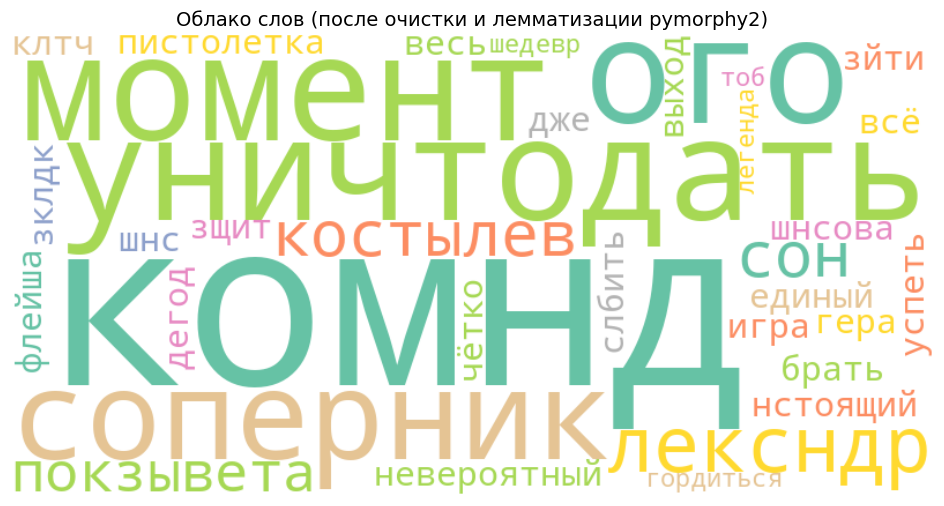

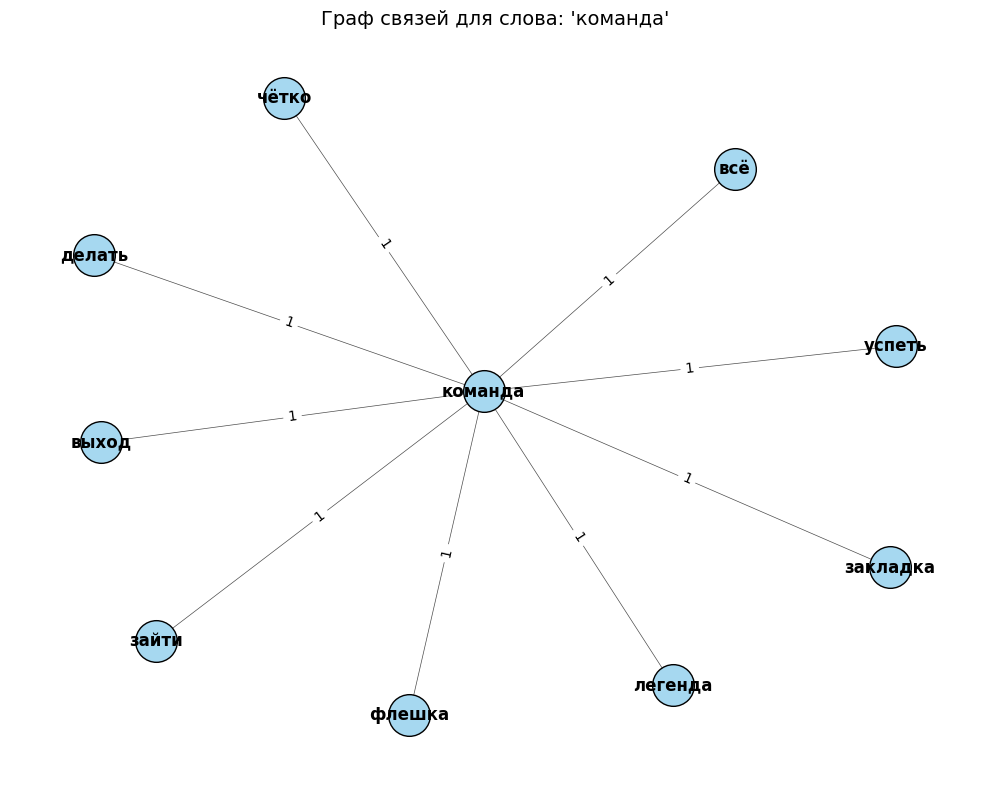

In [14]:

import re
import spacy
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import networkx as nx
import pymorphy3

# Инициализация
nlp = spacy.load("ru_core_news_sm")
morph = pymorphy3.MorphAnalyzer(lang='ru')  # ← работает в Python 3.12
russian_stopwords = set(stopwords.words("russian"))


# Эмоциональные паттерны
emotional_patterns = [
    r'о[о]+го+', r'вау', r'ух\s*ты', r'боже', r'ну\s+что\s+за', r'круто', r'фантастика',
    r'невероятно', r'жесть', r'отпад', r'класс', r'огонь', r'ух[х]*', r'аа+[а]*',
    r'ой', r'нуу+[у]*', r'просто', r'прямо', r'очень', r'совсем', r'вообще', r'а+[а]*х*[х]*',
    r'у+[у]*ра+', r'лол', r'гг', r'скилл', r'пздц', r'бб', r'флэш'
]
emotional_re = re.compile('|'.join(emotional_patterns), re.IGNORECASE)

def preprocess_text(text):
    # Удаляем эмоции
    text = emotional_re.sub('', text)

    # Используем spaCy ТОЛЬКО для извлечения именованных сущностей
    doc = nlp(text)
    ner_tokens = set()
    for ent in doc.ents:
        if ent.label_ in {'PER', 'PERSON', 'ORG', 'GPE', 'LOC', 'MISC'}:
            # Добавляем все слова из сущности в список на удаление
            for token in ent:
                ner_tokens.add(token.text.lower())

    # Теперь разбиваем текст на слова (просто по whitespace + пунктуация)
    # Удаляем пунктуацию и приводим к нижнему регистру
    words = re.findall(r"[а-яё]+", text.lower())

    clean_tokens = []
    for word in words:
        if word in ner_tokens:
            continue
        if word in russian_stopwords or len(word) < 3:
            continue
        # Лемматизация через pymorphy2
        parsed = morph.parse(word)[0]
        lemma = parsed.normal_form
        if re.fullmatch(r"[а-яё]+", lemma):
            clean_tokens.append(lemma)

    return clean_tokens

# Загрузка файла
from google.colab import files
print("Загрузите текстовый файл (.txt) с речью комментатора")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
with open(filename, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Предобработка
clean_tokens = preprocess_text(raw_text)

if not clean_tokens:
    print("После очистки не осталось слов. Проверьте входной текст.")
else:
    from nltk.util import ngrams

    # N-граммы
    unigrams = clean_tokens
    bigrams = list(ngrams(clean_tokens, 2))
    trigrams = list(ngrams(clean_tokens, 3))

    top_unigrams = Counter(unigrams).most_common(20)
    top_bigrams = Counter(bigrams).most_common(20)
    top_trigrams = Counter(trigrams).most_common(20)

    print("ТОП-20 униграмм:")
    for word, freq in top_unigrams:
        print(f"{word}: {freq}")

    print("\nТОП-20 биграмм:")
    for gram, freq in top_bigrams:
        print(f"{' '.join(gram)}: {freq}")

    print("\nТОП-20 триграмм:")
    for gram, freq in top_trigrams:
        print(f"{' '.join(gram)}: {freq}")

    # Облако слов
    wordcloud_text = ' '.join(unigrams)
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap='Set2', collocations=False, random_state=42).generate(wordcloud_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Облако слов (после очистки и лемматизации pymorphy2)", fontsize=14)
    plt.show()

    # === Граф связей ===
    target_word = "команда"  # ← измените при необходимости

    # Разбиваем исходный текст на предложения с помощью простого разделения по .!?
    sentences = re.split(r'[.!?]+', raw_text)
    context_graph = Counter()

    for sent in sentences:
        if not sent.strip():
            continue
        # Получаем леммы и фильтруем, как в preprocess_text, но сохраняем список слов в предложении
        words = re.findall(r"[а-яё]+", sent.lower())
        ner_in_sent = set()
        doc_sent = nlp(sent)
        for ent in doc_sent.ents:
            if ent.label_ in {'PER', 'PERSON', 'ORG', 'GPE', 'LOC', 'MISC'}:
                for token in ent:
                    ner_in_sent.add(token.text.lower())

        lemmas = []
        for w in words:
            if w in ner_in_sent or w in russian_stopwords or len(w) < 3:
                continue
            try:
                lemma = morph.parse(w)[0].normal_form
                if re.fullmatch(r"[а-яё]+", lemma):
                    lemmas.append(lemma)
            except:
                continue

        if target_word in lemmas:
            for w in lemmas:
                if w != target_word:
                    context_graph[(target_word, w)] += 1

    if context_graph:
        G = nx.Graph()
        for (w1, w2), freq in context_graph.items():
            G.add_edge(w1, w2, weight=freq)

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, k=2, seed=42)
        nx.draw_networkx_nodes(G, pos, node_size=900, node_color='#a6d8f0', edgecolors='black')
        nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
        weights = [d['weight'] for u, v, d in G.edges(data=True)]
        nx.draw_networkx_edges(G, pos, width=[w / 2 for w in weights], alpha=0.7)
        edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
        plt.title(f"Граф связей для слова: '{target_word}'", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Слово '{target_word}' не найдено в очищенных данных или не имеет связей.")

In [ ]:
# УСТАНОВКА ЗАВИСИМОСТЕЙ
!pip install -q spacy wordcloud matplotlib networkx pymorphy3

# Загрузка русской модели spaCy (для NER)
!python -m spacy download ru_core_news_sm

Загрузите .txt файл с речью комментатора


Saving commentary.txt to commentary (9).txt
ТОП-20 униграмм:
команда: 4
mple: 2
na: 2
vi: 2
шанс: 2
момент: 1
virtus: 1
pro: 1
уничтожать: 1
соперник: 1
александр: 1
снова: 1
показывать: 1
невероятный: 1
флейша: 1
брать: 1
пистолетка: 1
единый: 1
настоящий: 1
герой: 1

ТОП-20 биграмм:
na vi: 2
момент команда: 1
команда virtus: 1
virtus pro: 1
pro уничтожать: 1
уничтожать соперник: 1
соперник александр: 1
александр mple: 1
mple снова: 1
снова показывать: 1
показывать невероятный: 1
невероятный флейша: 1
флейша na: 1
vi брать: 1
брать пистолетка: 1
пистолетка единый: 1
единый шанс: 1
шанс настоящий: 1
настоящий герой: 1
герой весь: 1

ТОП-20 триграмм:
момент команда virtus: 1
команда virtus pro: 1
virtus pro уничтожать: 1
pro уничтожать соперник: 1
уничтожать соперник александр: 1
соперник александр mple: 1
александр mple снова: 1
mple снова показывать: 1
снова показывать невероятный: 1
показывать невероятный флейша: 1
невероятный флейша na: 1
флейша na vi: 1
na vi брать: 1
vi брать пист

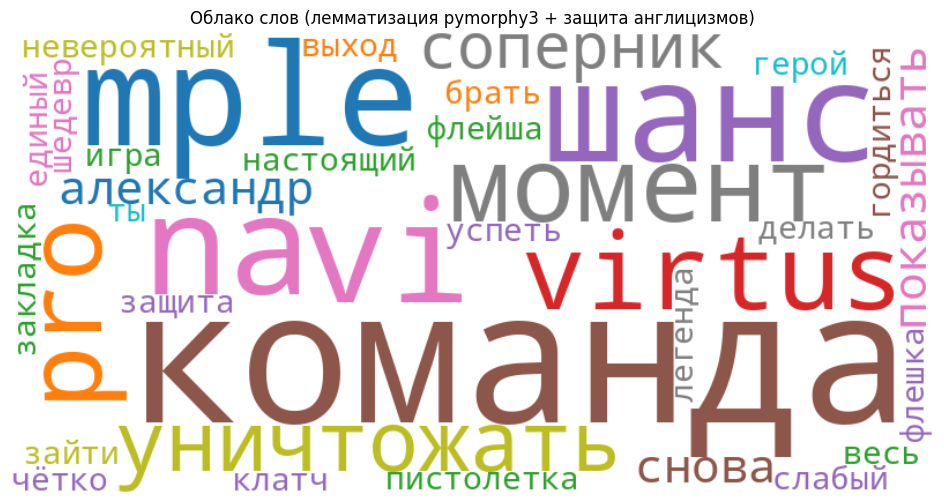

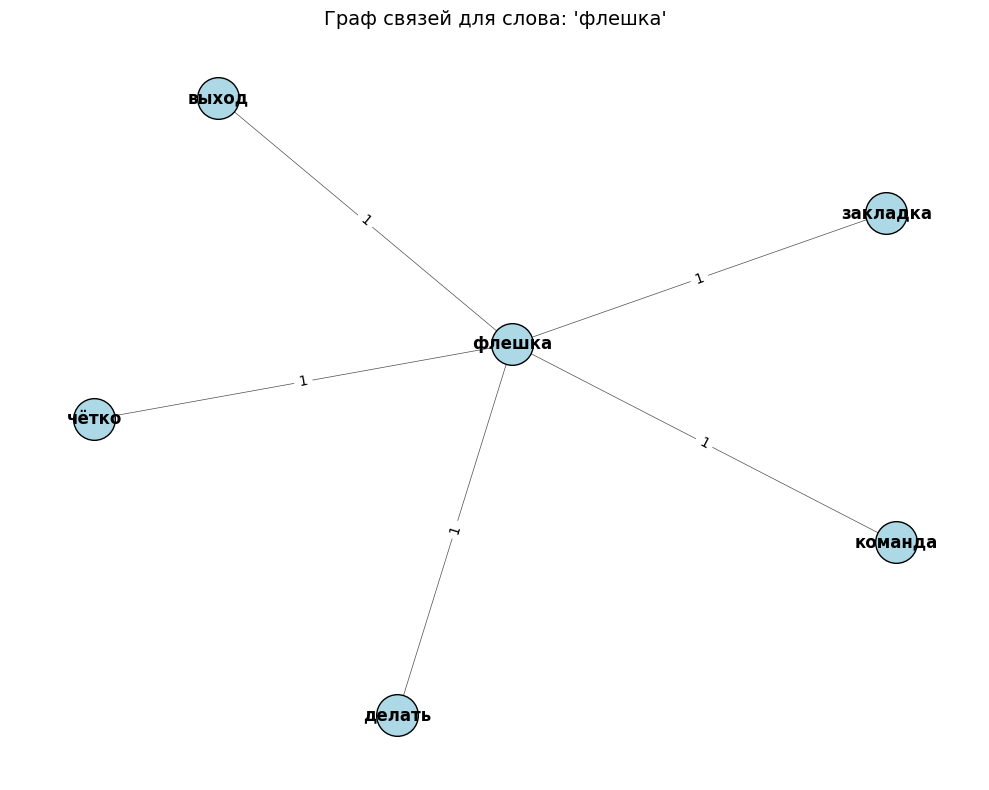

In [16]:

import re
import spacy
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import networkx as nx
import pymorphy3

# === ИНИЦИАЛИЗАЦИЯ ===
nlp = spacy.load("ru_core_news_sm")
morph = pymorphy3.MorphAnalyzer(lang='ru')

# Стоп-слова из NLTK + кастомные
russian_stopwords = set([
    'это', 'весь', 'сам', 'самый', 'который', 'такой', 'все', 'всё', 'мочь', 'ещё',
    'только', 'даже', 'сейчас', 'здесь', 'там', 'очень', 'просто', 'прямо', 'вообще',
    'совсем', 'немного', 'какой', 'свой', 'наш', 'ваш', 'их', 'его', 'её', 'ихний'
])

# Добавим NLTK-стоп-слова, если доступны
try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)
    russian_stopwords.update(stopwords.words('russian'))
except:
    pass

# Эмоциональные триггеры
emotional_re = re.compile(
    r'\b(ого|вау|ух\W*ты|боже|круто|фантастика|невероятно|жесть|отпад|класс|огонь|ой|лол|гг|бб|скилл|флэш|пздц|а+[аох]+|у+ра+)\b',
    re.IGNORECASE
)

# Слова, которые НЕ лемматизируем — оставляем как есть (киберспортивные англицизмы)
KEEP_AS_IS = {
    'скилл', 'флэш', 'флеш', 'клaтч', 'клатч', 'рейт', 'пуш', 'a', 'b', 'mid', 'site',
    'eco', 'pistol', 'buy', 'smoke', 'molotov', 'he', 'awp', 'deagle', 'ak', 'm4'
}

def lemmatize_word(word: str) -> str:
    word_lower = word.lower()
    if word_lower in KEEP_AS_IS:
        return word_lower
    parses = morph.parse(word)
    # Выбираем самый вероятный разбор с высоким скором
    best = max(parses, key=lambda p: p.score if hasattr(p, 'score') else 1.0)
    lemma = best.normal_form
    return lemma if re.fullmatch(r'[а-яёa-z]+', lemma) else word_lower

def preprocess_text(text: str):
    # 1. Удаляем эмоции
    text = emotional_re.sub('', text)

    # 2. Получаем список слов (только буквы кириллицы + латиница для англицизмов)
    tokens_raw = re.findall(r"[а-яёa-z]+", text.lower())

    # 3. Удаляем NER через spaCy
    doc = nlp(text)
    ner_words = set()
    for ent in doc.ents:
        if ent.label_ in {'PER', 'PERSON', 'ORG', 'GPE', 'LOC', 'MISC'}:
            for token in ent:
                ner_words.add(token.text.lower())

    # 4. Фильтрация и лемматизация
    clean = []
    for word in tokens_raw:
        if word in ner_words:
            continue
        if word in russian_stopwords or len(word) < 2:
            continue
        lemma = lemmatize_word(word)
        clean.append(lemma)
    return clean

# === ЗАГРУЗКА ДАННЫХ ===
from google.colab import files
print("Загрузите .txt файл с речью комментатора")
uploaded = files.upload()
filename = next(iter(uploaded))
with open(filename, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# === ОБРАБОТКА ===
tokens = preprocess_text(raw_text)

if not tokens:
    print("⚠ После обработки не осталось слов.")
else:
    from nltk.util import ngrams

    unigrams = tokens
    bigrams = list(ngrams(tokens, 2))
    trigrams = list(ngrams(tokens, 3))

    print("ТОП-20 униграмм:")
    for w, f in Counter(unigrams).most_common(20):
        print(f"{w}: {f}")

    print("\nТОП-20 биграмм:")
    for g, f in Counter(bigrams).most_common(20):
        print(f"{' '.join(g)}: {f}")

    print("\nТОП-20 триграмм:")
    for g, f in Counter(trigrams).most_common(20):
        print(f"{' '.join(g)}: {f}")

    # Облако слов
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='tab10', collocations=False, random_state=42).generate(' '.join(unigrams))
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("Облако слов (лемматизация pymorphy3 + защита англицизмов)")
    plt.show()

    # === ГРАФ СВЯЗЕЙ ===
    target = "флешка"

    # Разбиваем на предложения (просто по . ! ?)
    sentences = [s.strip() for s in re.split(r'[.!?]+', raw_text) if s.strip()]
    graph = Counter()

    for sent in sentences:
        sent_tokens = re.findall(r"[а-яёa-z]+", sent.lower())
        # Удаляем NER в предложении
        sent_doc = nlp(sent)
        ner_in_sent = {t.text.lower() for ent in sent_doc.ents if ent.label_ in {'PER','ORG','GPE'} for t in ent}
        lemmas = []
        for w in sent_tokens:
            if w in ner_in_sent or w in russian_stopwords or len(w) < 2:
                continue
            lemmas.append(lemmatize_word(w))
        if target in lemmas:
            for w in lemmas:
                if w != target:
                    graph[(target, w)] += 1

    if graph:
        G = nx.Graph()
        for (a, b), w in graph.items():
            G.add_edge(a, b, weight=w)
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, k=2, seed=42)
        nx.draw_networkx_nodes(G, pos, node_size=900, node_color='#add8e6', edgecolors='k')
        nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
        weights = [d['weight'] for u, v, d in G.edges(data=True)]
        nx.draw_networkx_edges(G, pos, width=[w/2 for w in weights], alpha=0.7)
        nx.draw_networkx_edge_labels(G, pos, edge_labels={(u,v):d['weight'] for u,v,d in G.edges(data=True)}, font_size=10)
        plt.title(f"Граф связей для слова: '{target}'", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Слово '{target}' не найдено в контексте.")